In [1]:
from PIL import Image
import torch
from xaikd import vitlrp, models, utils
import numpy as np 
from matplotlib import pyplot as plt
from torchvision import transforms as T
from torch.nn import functional as F
from zennit.attribution import Gradient

from datetime import datetime

In [2]:
device = utils.get_device()

device

'cuda'

In [3]:
img = Image.open('../../tests/data/castle.jpg')

In [4]:
normalizer = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
transform = T.Compose(
    [T.Resize(256), T.CenterCrop(224), T.ToTensor(), normalizer]
)

In [5]:
low_value, high_value = normalizer(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))
low_value, high_value

(tensor([[[[-2.1179]],
 
          [[-2.0357]],
 
          [[-1.8044]]]]),
 tensor([[[[2.2489]],
 
          [[2.4286]],
 
          [[2.6400]]]]))

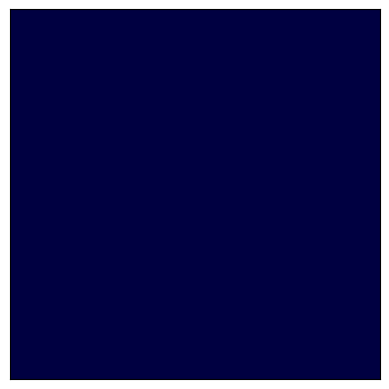

In [6]:
from matplotlib.colors import ListedColormap

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    grid_steps=4,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

_heatmap(np.zeros((224, 224)))

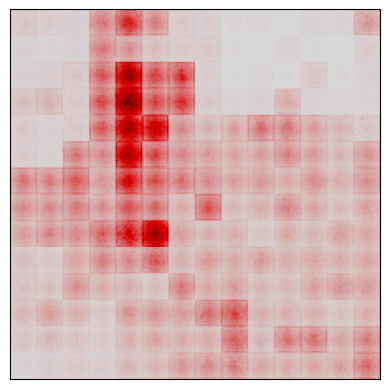

In [7]:
def compute_relevance(img, target, gamma=0.1, eps=0.1, first_layer_rule="box"):
    x = transform(img).unsqueeze(0).to(device)

    model = models.get_trained_model("imagenet-vitb-tv")
    model.to(device)

    with Gradient(
        model=model,
        composite=vitlrp._build_composite(lb=low_value, hb=high_value, first_layer_rule=first_layer_rule, gamma=gamma, eps=eps)
    ) as attributor:
        actual_output, relevance = attributor(
            x,
            lambda logits: logits * F.one_hot(torch.tensor([target]), 1000).to(device)
        )

    relevance = relevance.sum(axis=1).squeeze().detach().cpu().numpy()
    return actual_output, relevance

_, rel = compute_relevance(img=img, target=483)
_heatmap(rel)

pred_indices [483 970 663]
pred_indices [483 970 663]


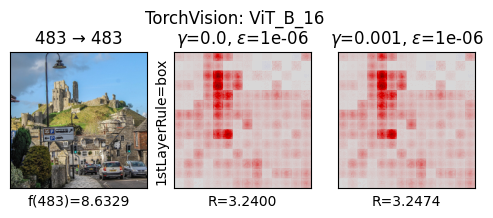

In [11]:
def sweep_gamma(
    img, target,
    first_layer_rule="box",
    arr_gammas=[0, 0.001, 0.01, 0.1, 1, 10],
    debug=False
):
    eps = 1e-6
    ncols = len(arr_gammas) + 1
    nrows = 1
    plt.figure(figsize=(2*ncols, 2))
    plt.suptitle("TorchVision: ViT_B_16", y=1.05)
    for i, gamma in enumerate(arr_gammas):
        logits, relevance = compute_relevance(
            img=img,
            target=target,
            gamma=gamma,
            first_layer_rule=first_layer_rule
        )
        logits = logits.detach().cpu().numpy()
        pred = np.argmax(logits[0, ])

        if debug:
            print("pred_indices", np.argsort(-logits[0, :])[:3])

        plt.subplot(nrows, ncols, i+2)

        plt.title(f"$\gamma$={gamma}, $\epsilon$={eps}")
        _heatmap(relevance)
        plt.xlabel(f"R={relevance.sum():.4f}")

        if i == 0:
            plt.ylabel(f"1stLayerRule={first_layer_rule}")

        if i == 0:
            plt.subplot(nrows, ncols, 1)
            plt.title(f"{target} → {pred}")

            plt.imshow(img); plt.xticks([]); plt.yticks([])

            plt.xlabel(f"f({target})={logits[0, target]:.4f}")

sweep_gamma(img, target=483, arr_gammas=[0.0, 0.001], debug=True)

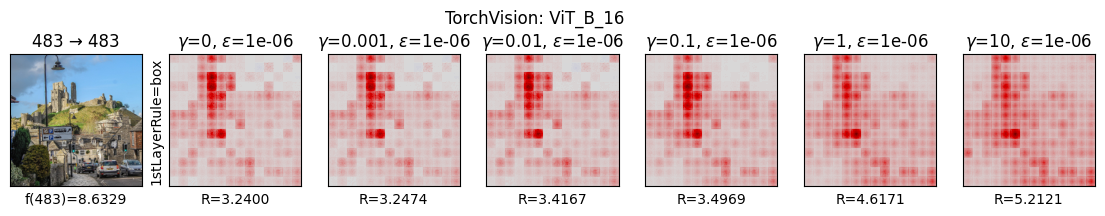

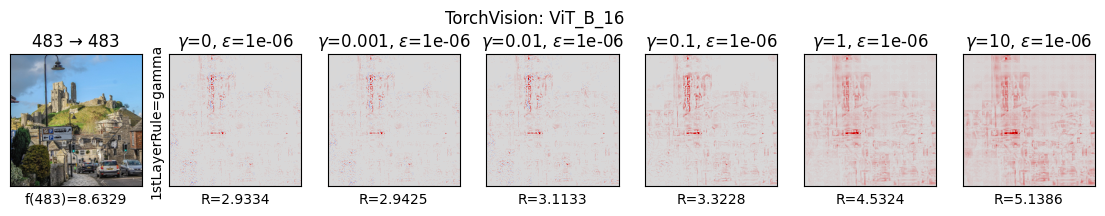

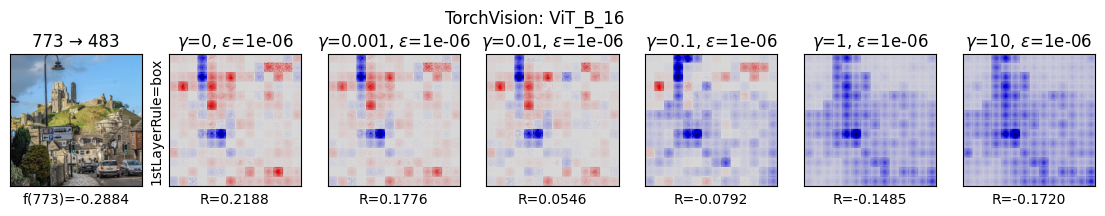

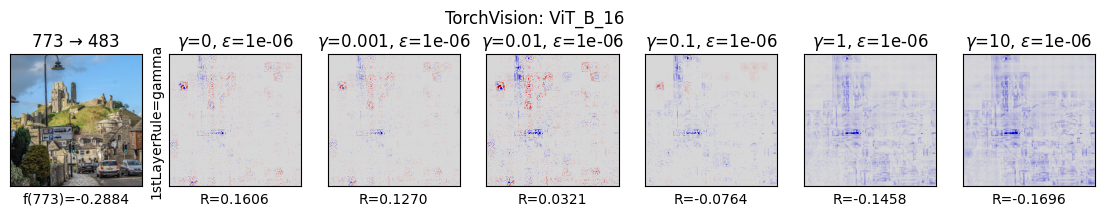

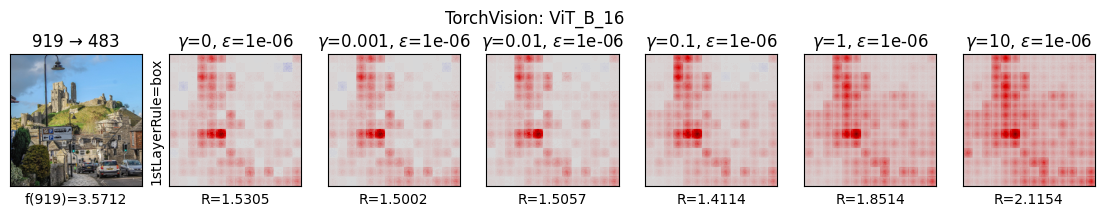

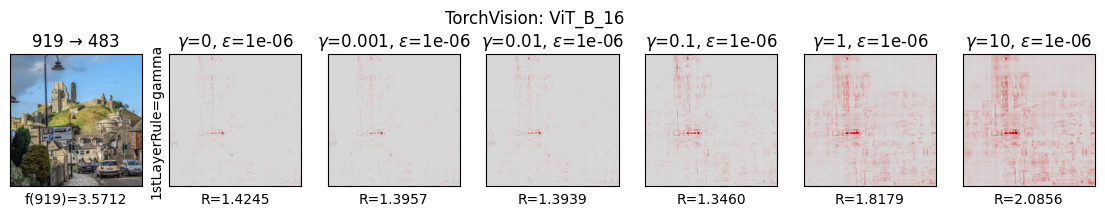

In [12]:
for target in [
    483, # castle
    773, # pole
    919, # streetsign
]:
    for first_layer_rule in ["box", "gamma"]:
        sweep_gamma(img, target=target, first_layer_rule=first_layer_rule)
        plt.show()

In [13]:
print(f"Finished at {datetime.now()}")

Finished at 2024-09-19 04:56:14.183843
